<h2>OBSERVATIONAL ASTROPHYSICS – FALL 2026 OBSERVING EXERCISE (50 points)</h2>
<h4>All elements are due by October 2nd at noon.</h4>

<i>Note: Enter in all code to the problems in the provided notebook cells. Questions to answer will be <b>bolded</b>.</i>  

The goal of this exercise is to give you experience in planning an observation as if you would be preparing a telescope proposal.  For the purpose of this exercise we will be using a telescope at Siena University in the vicinity of Albany, NY.  The telescope and camera are described below.

All your answers should be entered using the python notebook templates provided as part of this assignment. Each student will need to hand in their own notebook by uploading it to GitHub.   Just make a repository called `Observing Exercise` and send me the link.  You don't need to make me a collaborator.

In the code places where you will need to put something or write your own code are specified by `#***************`

### Do not attempt Problems 1 and 6 until the second week.

To plan your observing, you need to derive a few basics about the combined scope/ instrumentation. The <a href = "https://planewave.com/products/cdk700/">0.7m Breyo telescope</a> at Siena has an optics combination that results in an effective f/6.5 ratio.  In this case the 'f/6.5' is a convention for saying a focal ratio of 6.5. It is equipped with an electronically cooled <a href = "https://cdn.prod.website-files.com/6787ccd15f899cb85836f2b9/697a58dc7456ba24cbc39603_KL4040FI.pdf">  Kepler KL4040FI camera</a> and a filter wheel assembly from Finger Lakes Instrumentation.  

The link above gives you the technical specifications for the CCD.  Use those on the first page.  Note that "4k" in astronomy language means 4096.

<b>1)    Given the CCD type and the telescope optics: (5 points)
    <li>a) What will be the size in arcseconds of the typical CCD pixel on the KL4040 chip.
    <li>b) What is the field of view (FOV) of the 0.7m CMOS camera in arc minutes? By FOV I mean the length of one side of the detector. </li>
</b>
    

   

In [25]:
#Answer 1) Here
#You will need to use simple mathematical expressions and what you learned in class to find the asnwers to these.  
#In order to get credit for this part you will need to write an expression that properly executes and results in the answer
#You will need an expression for both parts 1 and 2 above

#******************
#part a
#from class, pixel scale is just theta/y = 1/f, where f is the focal length, and the focal length here is 6.5 --> 206265/f
#nope that's the focal ratio, which is given by: R = f/D, where D is the diameter of the aperture.
#also am going to use what's said in the slides: pixels on a detector have a fixed size, often 15 microns --> d
#i lied again, I literally started part b and it said the size of the pixels were 9 microns so I have to change that for this problem :/
#left my previous work in comments though
f_ratio = 6.5
D = 0.7 #meters
d = 9*10**(-6) #15*10**(-6) # the pixel size converted to meters
f = f_ratio*D #this gives the focal length in meters, which we're going to have to convert to microns for pixel scale, I think
print("The focal length is: ", f) #this matches what's on the website too
s = 206265/f #this gives answer in arcsec/meters.
s_p = s*d #s_p = sd, answers arcsec/pixels
print("The size of a typical CCD pixel in arcseconds is: ", s_p, "arseconds") #prints the answer :)


#part b
#from class, the FOV is determined by the size of the detector & pixel scale
#4096x4096, pixel size: 9 microns --> went and redid part a for the pixel size part
#formula is: FOV = pixel scale * size of detector
detector_size = 4096 #pixels
pixel_scale = s_p
FOV = pixel_scale*detector_size # gives answer in arcseconds, which to convert to minutes, we just divide by 60
FOV_am = FOV/60 #gives answer in arcminutes
print("The FOV in arc minutes is: ", FOV_am)

The focal length is:  4.55
The size of a typical CCD pixel in arcseconds is:  0.4079967032967033 arseconds
The FOV in arc minutes is:  27.852574945054943


For the purpose of this exercise we will assume that we will observe on October 7th. We will need to begin the telescope setup procedure about 1 hour before Sunset so that we are ready to begin taking frames once it becomes dark enough to observe and we can take some calibration frames while the sky is still bright enough. (Note: since in this example we are observing from near Albany, NY, all the questions below need to be answered as if you were in Albany. We can then subtract 1 hour from the times to account for the local observing schedule.) 

<b><u>2)    When does sunset occur on Oct. 7?  (5 points)</u></b>  <i> The end of the code prints your answer in UTC. You need to also print it in Albany and Lawrence time.</i>

In [3]:
#There is a function in the python package astroplan to find the sunset time for a given location and date:
#    https://astroplan.readthedocs.io/en/latest/api/astroplan.Observer.html#astroplan.Observer.sun_set_time
#This function is a part of the observer class, and takes an input Time object from astropy corresponding to 
# the date. See documentation for astropy's Time object here for reference if needed:
#    https://docs.astropy.org/en/stable/api/astropy.time.Time.html
#Here's an example of how this function works:
#
#    Time_date = Time('2001-05-27')
#    observer_object = Observer(longtiude = -155.0903*u.deg, latitude = 19.7026*u.deg, elevation = 100.0*u.m, name = "Subaru",timezone = "US/Hawaii")
#    sunset_time = observer_object.sun_set_time(Time_date, which = "next")
#
#Note here that Time_date is the date of observation, and which="next" instructs the function to provide the next sunset time
#For details on the observer object, to be used throughout this assignment, see here:
#    https://astroplan.readthedocs.io/en/latest/api/astroplan.Observer.html
#In general, the observer object takes in a longtiude, latitude, elevation (we assign this as 0), a name of your choice, and a timezone.
#You can view a list of available timezones on this stackoverflow thread:
#    https://stackoverflow.com/questions/13866926/is-there-a-list-of-pytz-timezones


#We import the necessary packages for this section
from astroplan import Observer
from astropy.time import Time
import astropy.units as u
#import warnings
#warnings.filterwarnings("ignore")

#****************
#Here you will need to define the coordinates of the Breyo observatory. Note that W and S have negative values (whereas E and N are positive).
#The latitude and longitude need to be put in decimal form, e.g. long = 20.0003, lat = 33.33333 (those are not the right coordinates)
_LONGITUDE_ = -73.752 #*******************
_LATITUDE_ = 42.720  #*******************

#This is an astropy Time object, with a time value that corresponds to the date of observation. Date format: Time('YYYY-MM-DD')
_TIME_ = Time('2026-10-07') #*******************


#You now need to make the observer object for the Breyo observatory. See the example above for help
Breyo_observer = Observer(longitude = _LONGITUDE_*u.deg, latitude = _LATITUDE_*u.deg, elevation = 43.0*u.m, name = "Breyo",timezone = "US/Eastern") 

#This computes the sunset at the time specified by the TIME object, at the location defined by Breyo_observer
sunset_time = Breyo_observer.sun_set_time(_TIME_, which = "next") 

#The following provides a useful way to print out astropy Time objects in a convenient way. 
#The time returned here is in UTC time
print("Sunset: {0.iso}".format(sunset_time)) 

#*****************
#put calculation here to find sunset time at Breyo and in Lawrence.  Also include code to print answers.
#Lawr_LONGITUDE = -95.24
#Lawr_LATITUDE = 38.97

#Lawr_observer = Observer(longitude = Lawr_LONGITUDE*u.deg, latitude = Lawr_LATITUDE*u.deg, elevation = 39.0*u.m, name = "Lawrence", timezone = "US/")

#sunset_time = Lawr_observer.sun_set_time(_TIME_, which = "next")
#Literally ignore everything above this, I misread the problem :)

UTC_B = sunset_time - (4/24) #-4 hours, convert hours to decimal days by dividing by 24
print("Sunset in Breyo: {0.iso}".format(UTC_B)) #What time the sunset happens in Breyo
UTC_L = sunset_time - (5/24) #-5, same reason as above
print("Sunset in Lawrence: {0.iso}".format(UTC_L)) #What time the sunset happens in Lawrence

Sunset: 2026-10-07 22:21:14.363
Sunset in Breyo: 2026-10-07 18:21:14.363
Sunset in Lawrence: 2026-10-07 17:21:14.363


Note – technically, sunset refers to the moment when the entire disk of the sun sinks below the horizon. However, the sky is still quite bright because of scattered/refracted light from the seeing sun. The next key moment is the end of twilight, defined as the moment when the sun’s center is a certain number of degrees below the horizon: civil twilight = 6°, astronomical twilight = 18°. At astronomical twilight, it should be totally dark (Moon excluded).

<b><u>3)    When does <font color="red">astronomical twilight</font> occur on Oct. 7? (5 points)</u></b>

In [10]:
#There is an astroplan function that can be used to find astronomical twilight for a given time and position(observer):
#    https://astroplan.readthedocs.io/en/latest/api/astroplan.Observer.html#astroplan.Observer.twilight_evening_astronomical
#This function is a part of the observer class in astroplan, and its inputs are a time object corresponding to
#the date of observation, and an argument which, with possible values previous, nearest, or next, chooses
#the corresponding astronomical twilight to find
#Example:
#    observer_object = Observer(location=location, name="Subaru", timezone="US/Hawaii")
#    astro_twilight = observer_object.twilight_evening_astronomical(Time_date, which = "next")

###
#*******************
#Answer 3) Here. YOUR CODE: 

astro_twilight = Breyo_observer.twilight_evening_astronomical(_TIME_, which = "next")

#The following provides a useful way to print out astropy Time objects in a convenient way. 
print("Astronomical Twilight UTC: {0.iso}".format(astro_twilight)) 


Astronomical Twilight UTC: 2026-10-07 23:59:29.045


Convert the UTC output to the local time both at the Breyo Observatory and in Lawrence and put the answer and the calculation in the next cell. The result of the cell should print out the twilight time at both locations.

In [13]:
#(Continued) Part 3 answer goes here
#*******************

#Lawrence time
Lawr_twilight = astro_twilight - 5/24 #had to subtract the hours converted to decimal days to account for the timezone difference
print("Astronomical Twilight in Lawrence Time: {0.iso}".format(Lawr_twilight))

#Breyo time
Breyo_twilight =  astro_twilight - 4/24 #same reason as above
print("Astronomical Twilight in Breyo Time: {0.iso}".format(Breyo_twilight))

Astronomical Twilight in Lawrence Time: 2026-10-07 18:59:29.045
Astronomical Twilight in Breyo Time: 2026-10-07 19:59:29.045


Let AT = Astronomical Twilight.  Assume we will be observing at AT + 0.0 HR to AT + 1.5 HRS on Oct. 7th.

<b><u>4) What is the optimum range of RA for objects that you would ideally observe during this 1.5-hour session?  (5 points)</u></b> Note: <i>Think about whether objects of a given RA are rising or settng at the beginning and end of your observation session.</i>

Go to the web page https://aa.usno.navy.mil/data/siderealtime to find the sidereal time at different local times.  

Enter the information in the empty markdown box below and make sure to give a rationale as to why this range of RA is appropriate.

*Answer for 4 goes here:*
The end of the observation time would be at about 1:29:29.045 on October 8th, which is an hour and a half after astronomical twilight. The LST in Breyo at astronomical twilight in UTC is 20:11:03.0605. And at the end of the observation session, the LST in Breyo is 21:41:17.845. So I think the range in the RA is 20:11-21:41.   

<b>5) If you want to remain within 30° of the zenith, what is the optimum range in declination? You need to answer this in two parts: (10 points)</b> 

a. <b>Given the location of the observatory, objects at their transit need to have what range of declination to be within 30° of the zenith.</b><i> This requires a straightforward calculation</i>
        


In [30]:
#Answer 5a) Here
#*******************
#Part 1:
#   Figure out how to use the observatory's location to find the position of the zenith.
#zenith is just the point overhead, so in this case, I think you can say that the declination of the zenith is equal to the latitude
zenith_declination = _LATITUDE_
#and I think 30 degrees within means 30 degrees in either direction, above and below the declination of the zenith
declination_above = zenith_declination + 30
declination_below = zenith_declination - 30

print("Declination of zenith is: ", zenith_declination)
print("Upper limit of Declination is: ", declination_above)
print("Lower limit of Declination is: ", declination_below)


Declination of zenith is:  42.72
Upper limit of Declination is:  72.72
Lower limit of Declination is:  12.719999999999999


b. <b>Using airmass plots (see below), determine what range of declinations would keep objects within 30° of the zenith over the course of your 1.5 hour observation block. Your answer will need to include airmass plots to demonstrate this. These plots can contain multiple curves, e.g. for different RA and DEC combinations, as long as the curves are labeled. All plots should come with a caption.</b>


AttributeError: 'Axes' object has no attribute 'plot_date'

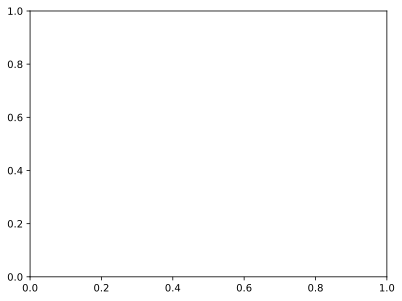

In [34]:
#Here, we will provide you with the code needed to make airmass plots. You will use this to guide your answer to 5b
###We important all the needed packages
from astropy.coordinates import SkyCoord
from astroplan import FixedTarget
from astroplan.plots import plot_airmass, plot_altitude
import matplotlib.pyplot as plt
import numpy as np
%config InlineBackend.figure_format = 'svg' #This makes the plots appear better inline in the notebook
###

fig, ax = plt.subplots() #These are the matplotlib Figure and and Axis objects we will plot on

#*******************
#you will need to enter an observation time in UT time format 'YYYY-MM-DD HH:MM:SS'.  
#For this problem, you will need to change this time such that the x-axis of the plot
#starts just before sunset.  Note the time zone of the x-axis in the plot to determine what 
#the right time units are to put in the line below.
observation_time = Time('2026-10-07 18:00:14.363') #I took the sunset time we calculated in question 2 from Breyo and just set it 20 minutes before

#*******************
#Now, you must define the coordinates for a target in the sky, for which the airmass plot will be made.
#You will have to think about how to define these coordinates to find your answer for question E.2
#With these coordinates, we make a target object using the FixedTarget function from astroplan.
#Using the RA range from Part D, you should play with the DEC parameter until you find which DEC
#values satisfy the altitude constraint.  The `*u.deg` apply degree units to the number.
target_coord = SkyCoord(ra= 314.00*u.deg, dec= 6.00*u.deg) #chose an RA of about 20:56:03
target_source = FixedTarget(coord=target_coord, name="Target")

#We now actually construct the airmass plot. The plot_altitude function makes the airmass plot, with the elevation on the y-axis
plot_altitude(target_source,Breyo_observer, observation_time)

#We will now plot a line and shaded region at and above an elevation of 60 degrees
xmin, xmax = ax.get_xlim()
x_line = np.linspace(xmin,xmax,100)
y = [60]*100
ax.plot(x_line, y, ls = '--')
ax.fill_between(x_line, 60, 90, alpha = 0.1, color= 'orange' )

plt.show()

#need to use the website linked in slides, come back to later


In [ ]:
#*******************
#Remainder of Answer 5b) Here

#Part b: 
#   You will need to make a series of airmass plots using the code above to figure out which declinations satisfy the requirement here.
#   You can copy the code from above to make the airmass plots! 
#




In [36]:
#***Run this block but DO NOT CHANGE***

#Nothing to do here. Just some things defined for use later. 
from astroplan.plots import plot_finder_image
from astropy.coordinates import SkyCoord
from astroquery.skyview import SkyView
import astropy.units as u
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
%config InlineBackend.figure_format = 'svg' #This is here to make the plots appear high-resolution

def get_RA_deg(RA_HMS):
    #Convert RA from HMS to decimal degrees
    H, M, S = [float(i) for i in RA_HMS.split()]
    rs = 1
    if str(H)[0] == '-': 
      rs, H = -1, abs(H)
    deg = (H*15) + (M/4) + (S/240)
    RA = '{0}'.format(deg*rs)
    return float(RA)
    
def get_DEC_deg(DEC_DMS):
    #Convert DEC from DMS to decimal degrees
    ds = 1
    D, M, S = [float(i) for i in DEC_DMS.split()]
    if str(D)[0] == '-':
      ds, D = -1, abs(D)
    deg = D + (M/60) + (S/3600)
    DEC = '{0}'.format(deg*ds)
    return float(DEC)

For our detector and telescope a star of 20th magnitude in B and V gets 889 and 953 photons respectively in a 100s exposure.  The star’s light is spread over 10 pixels.  Let us conservatively (because the brightness is high then) assume that we are observing 1 day from full moon.  In that case the background per pixel is 194.2 and 144.8 in the B and V band respectively in a 100 sec. exposure.  Every pixel in our detector has a random signal (or noise) that is introduced whenever the signal is read out from the detector.  This "readnoise" is 3.7 counts per pixel.  Describe in a text cell below your computational cell whether or not you can neglect the read noise when determining the signal to noise, and why?
    
From the numbers above you can calculate the the faintest magnitude that yields you a SNR=20 in 15 minutes.

<b>6 . Your code should print out the following, with explanatory text.  There should be separate values given for B and V.  Each part is worth 2 points: (10 points)
    <li>a) total number of background counts in B and V in 15min for the 10 pixels in an object aperture;
    <li>b) the noise from the background in 15min for the summed pixels in an object aperture;
    <li>c) the number of counts in 15min for B and V that correspond to the desired SNR=20;
    <li>d) the number of counts in B and V for a 20th magnitude star in 15min;
    <li>e) the magnitude in B and V corresponding to the limiting number of counts in c).
</b>

For this calculation, assume the gain is 1.  This means that if I get one photon, my CCD counts 1 electron.  Since Poisson noise is computed on the incident photons and not the number of measured electrons, you need to convert your counts to photons.  We will assume for now that this is a 1-to-1 conversion (Gain=1).  This is not correct but will be ok for this calculation.

In [63]:
#Answer 6) Here
#YOUR CODE GOES HERE

#Hint: You need to use the information about the number of counts 
#for different sources that I give above.
t_exp = 100 #seconds
bgcts_B = 194.2
bgcts_V = 144.8
#following gives the pixels per second for the t_exp
bgcts_pixpersec_B = bgcts_B / t_exp
bgcts_pixpersec_V = bgcts_V / t_exp

#bg counts over the 15 min and 10 pixel light spread
#have to multiply the pixel per second by the pixel spread of light and the total exposure time in seconds
pixel_spread = 10
total_t_exp = 15*60 #to convert to seconds --> 900 seconds
bgcts_tot_t_exp_B = bgcts_pixpersec_B*pixel_spread*total_t_exp
bgcts_tot_t_exp_V = bgcts_pixpersec_V*pixel_spread*total_t_exp

#starting part b --> for large N values (which we have), sigma = sqrt(N)
#so i'm just going to do that with the total bg cts we calculated in pt a
bg_noise_B = np.sqrt(bgcts_tot_t_exp_B)
bg_noise_V = np.sqrt(bgcts_tot_t_exp_V)

#part c --> from class slides: SNR = N/sqrt(N)
#or actually let's try this: 20 = S/sqrt(N), where S is the star's noise
#and so
lim_count_B = 20*bg_noise_B
lim_count_V = 20*bg_noise_V


#part d: use 889 and 953 from the problem for B and V; also need to use the total_t_exp again
mag20_B = 889
mag20_V = 953
#and I think you just multiply this by the total exposure time like before?
#nope I lied. this is for the 100 second count, so we have to subtract that from the total exposure time
mag20_15m_B = mag20_B*(total_t_exp-100)
mag20_15m_V = mag20_V*(total_t_exp-100)


#part e: 
#okay so magnitude equation: m1 -m2 = -2.5log(f1/f2)
#we already know one of the magnitudes is 20 (m2), and we're trying to find the limiting magnitude (m1).
#we also already have our limiting counts for B and V (f1), and the counts for the 20 mag star (f2).
#just need to plug everything in:
lim_mag_B = -2.5*np.log10(lim_count_B / mag20_15m_B) +20
lim_mag_V = -2.5*np.log10(lim_count_V / mag20_15m_V) +20



#In each band, think about the noise from the background over the 
#whole size of the source when observed in 15min.  From this and the 
#SNR requirement you can determine the number of object counts that you need 
#to have the required SNR (see lecture notes).  Finally, the flux from a 
#20th mag object can then be used to convert that number of counts to a 
#limiting magnitude.

#first measure the total background expected in 15 minutes
print(f"a) The number of BKG counts in B and V in 15min is: {bgcts_tot_t_exp_B} and {bgcts_tot_t_exp_V}")

print(f"b) BKG noise in B and V: {bg_noise_B} and {bg_noise_V} ")

#now determine the number of object counts needed in 15 minutes to get the desired SNR.  
print(f"c) limiting counts for SNR limit in B and V: {lim_count_B} and {lim_count_V} ")

print(f"d) the number of counts in B and V for a 20th mag object in 15min: {mag20_15m_B} and {mag20_15m_V}")

print(f"e) magnitude limits in B and V corresponding to our SNR limit: {lim_mag_B} and {lim_mag_V} " )


a) The number of BKG counts in B and V in 15min is: 17478.0 and 13032.000000000002
b) BKG noise in B and V: 132.2043872191842 and 114.1577855426427 
c) limiting counts for SNR limit in B and V: 2644.0877443836844 and 2283.155710852854 
d) the number of counts in B and V for a 20th mag object in 15min: 711200 and 762400
e) magnitude limits in B and V corresponding to our SNR limit: 26.0742897119813 and 26.309118390790154 


<b> 7) You are going to prepare to observe the open cluster M34.  I have downloaded the GAIA catalog for this cluster and put it in your directory.  The magnitudes for this cluster are $m_{BP}$ and $m_{RP}$, which correspond very roughly to $B$ and $R$ magnitudes.  Your completed version of the Jupyter Notebook template will need to have for each cluster: (10 points) 
    <li>a) A color-magnitude diagram of the $m_{BP}-m_{RP}$ vs $m_{RP}$-band for all the stars in the cluster field.  
    <li>b) A histogram of the $m_{RP}$-band magnitudes of the cluster members
    <li>c) A description of what happens to the CMD when you increase the required precision of the parallaxes.
    <li>d) A plot of the RA and DEC of the cluster with an outline of the field of view of the detector centered on the cluster.  This is called a `finder chart`
    <li>e) A description of what the brightest star in the cluster is.

</b>


To do a) and b) I provide you with a way to make CMDs and a histogram of the $m_{RP}$-band magnitudes.
<ol>  
    <li>I have provided you with a table that includes the magnitudes of stars in this cluster  </li>
    <li>You should then use the make_plots() function (defined below), by passing as input the string of your file name (ex: "csv").  Please note that you need to use the cell block below the block of code directly below this text cell where the function is defined (if you try to call make_plots() before the cell it is written in you will get an error). You also need to make sure that the file with the data (there will be different ones for each cluster) is in the same directory as where the notebook is.  This isn't a generic requirement of such codes, but what we are doing here.</li>
</ol>

To do part d I include at the very bottom a block of code that will make a finder chart for a given RA and DEC.

In [39]:
#***RUN THIS BLOCK. If you wish to change the font sizes in the plots, you can do so here.  ***
from astropy.io import ascii

#Now we just define some settings for our plots. 
params = {
    #'text.latex.preamble': ['\\usepackage{gensymb}'],
    'image.origin': 'lower',
    'image.interpolation': 'nearest',
    'image.cmap': 'gray', #gray
    'axes.grid': False,
    'savefig.dpi': 300,  
    'axes.labelsize': 14, # fontsize for x and y labels
    'axes.titlesize': 20, 
    'font.size': 14, 
    'legend.fontsize': 10, 
    'xtick.labelsize': 12,
    'ytick.labelsize': 12, 
    'text.usetex': False,
    'figure.figsize': [6, 6], #[width, height]
    'figure.autolayout': False,
    'font.family': 'monospace',
}
matplotlib.rcParams.update(params) #activate the settings

def make_plots(file_name, parallax_over_error_min):
    print("********************************************")
    print("Plots for file: "+file_name)
    print("********************************************")
    #We load in the first 4 columns of the file

    data = ascii.read(file_name)
    #data = np.loadtxt(file_name,skiprows = 0,usecols = (0,1,2,3), dtype={'names': ('No', 'Ref', 'V', 'B-V'), 'formats': ('S8', 'S16', 'S16','S16')})
    
    #We need to handle duplicates in the file, so we find indeces of unique sources
    indeces_use = []
    len_data = len(data)
    for i in range(1,len_data-1): #Skip first row since it contains columns names.
        if data[i][0] != data[i+1][0]: #Check if the next source is a repeat
            indeces_use.append(i) #If it is not a repeat, it is unique and we record its index.
            
    num_sources = len(indeces_use) #Number of actual unique sources
    
    # #We will now average over the magnitudes for repeated sources
    # V_avg = np.zeros(num_sources)
    # BV_avg = np.zeros(num_sources)
    # for i in range(num_sources):
    #     current_index = indeces_use[i] #Keep track of the first index that this source appears at
    #     num_i = 1 #Keep track of the number of sources with this source name
    #     V_tot = float(data[current_index][2])
    #     BV_tot = float(data[current_index][3])
    #     #While the next source has the same source name
    #     while current_index < (num_sources - 2) and data[current_index][0] == data[current_index+1][0]:
    #         current_index += 1 #We go to the next repeat of this source.
    #         num_i += 1 
    #         V_tot += float(data[current_index][2]) #Add the next value forn this repeated source to the total mag
    #         BV_tot += float(data[current_index][3])
    #     V_avg[i] = V_tot/num_i
    #     BV_avg[i] = BV_tot/num_i

    parflag = data['parallax_over_error']>parallax_over_error_min

    bp_rp = data['phot_bp_mean_mag'][parflag] - data['phot_rp_mean_mag'][parflag]
    rp = data['phot_rp_mean_mag'][parflag]

    
    #Make the figure for the CMD
    fig1, ax1 = plt.subplots()
    ax1.set_xlabel(r'$m_{BP} - m_{RP}\ [mag]$')
    ax1.set_ylabel(r'$m_{RP}\ [mag]$')
    ax1.grid(which= 'major', linestyle='-', linewidth='0.5', color = 'black', alpha = 0.3)
    ax1.grid(which='minor', linestyle=':', linewidth='0.3', color = 'black', alpha = 0.2)
    ax1.scatter(bp_rp,rp, marker = '.', c='k')

    #Create good min and max values for CMD axes, and set axis limits. 
    x_min_plot = np.min(bp_rp)-0.4
    x_max_plot = 1.1*np.max(bp_rp)
    y_min_plot = np.min(rp)-abs(.1*np.min(rp))
    y_max_plot = 1.1*np.max(rp)
    ax1.set_xlim([float(x_min_plot), float(x_max_plot)])
    ax1.set_ylim([float(y_max_plot), float(y_min_plot)])
    ax1.set_title(r'Color Magnitude Diagram')

    #Make figure for histogram. 
    fig2, ax2 = plt.subplots()
    ax2.hist(rp, bins = 'auto',histtype ='step', color = 'k', lw = 1.5)
    ymin_hist, ymax_hist = ax2.get_ylim()
    xmin_hist, xmax_hist = ax2.get_xlim()
    #Write on the number of total sources for reference
    ax2.annotate( 'N = '+str(num_sources), xy = ( xmin_hist + 0.05*(xmax_hist-xmin_hist), ymax_hist - 0.1*ymax_hist))
    ax2.set_title(r'$m_{RP}$ mag Histogram')
    ax2.set_xlabel(r'$m_{RP}\ [mag]$')
    ax2.set_ylabel(r'Counts')

********************************************
Plots for file: rudnick-M34.csv
********************************************


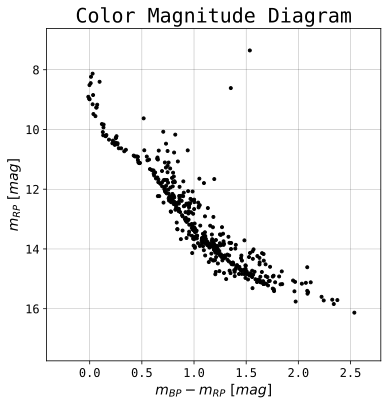

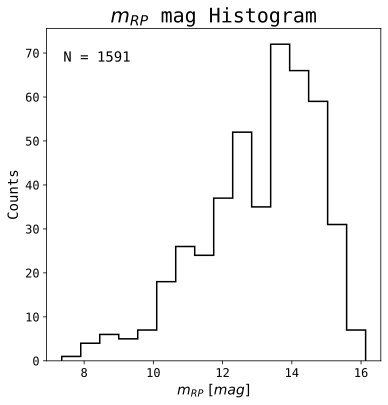

In [53]:
#*****************
#In this block of code you will make a CMD plot and a V-band magnitude histogram.
#You will need to repeat this for each cluster.

#Example call of make_plots for the file "cluster.csv"
#   
#    make_plots("cluster.csv",parallax_over_error_minimum)
#
#Replace "cluster.csv" with the name of the csv file in your directory
#the parallax_over_error_minimum is a value equal to parallax/delta_parallax
#YOUR CODE HERE

make_plots("rudnick-M34.csv",35)

7c) <i>Describe how the CMD changes when you increase the required precision of the parallaxes.  You can do this by changing the parallax_over_error_minimum parameter when you call the `make_plots` function in 7b.  </i>\
Well, the plotted points are moving up and to the right, and the greater the precision, the fewer points are plotted.

In [54]:
#***RUN THIS BLOCK***
#This is a routine to pull images from the web at the location of your source and 
#to overlay the Breyo telescope KL4040 camera's field of view

def make_finder(RA_HMS, DEC_DMS, fov, img_width=40./60, img_height=40./60,title='Generic Cluster'):
    #Use the RA and DEC to make a SkyCoord object, which we use to query and image
    RA_DEG = get_RA_deg(RA_HMS) #convert to Degrees
    DEC_DEG = get_DEC_deg(DEC_DMS)
    source_coord = SkyCoord(ra= RA_DEG*u.deg,dec = DEC_DEG*u.deg)

    #Query an image using astroquery with the given coordinates and image width/height
    #xout = SkyView.get_images(SkyCoord(ra=127.4*u.deg, dec=+52.223*u.deg), survey=['SDSSg'], height=40./60 * u.deg, width = 40./60 * u.deg)
    
    xout = SkyView.get_images(source_coord,survey=['DSS'],height=img_height*u.deg,width=img_width*u.deg)
    
    #Make the figure object and handle the fits image appropriately.
    fig, ax = plt.subplots(figsize=(8,8))
    b=xout[0][0]
    ax.imshow(xout[0][0].data,aspect='equal',cmap='gray_r',extent=[b.header['CRVAL1']-(b.header['NAXIS1']-b.header['CRPIX1'])*b.header['CDELT1'],
                                                               b.header['CRVAL1']+(b.header['NAXIS1']-b.header['CRPIX1'])*b.header['CDELT1'],
                                                               b.header['CRVAL2']+(b.header['NAXIS2']-b.header['CRPIX2'])*b.header['CDELT2'],
                                                               b.header['CRVAL2']-(b.header['NAXIS2']-b.header['CRPIX2'])*b.header['CDELT2']])
    #Overlay a rectangle indicating the fov
    rect = plt.Rectangle((RA_DEG-0.5*(fov),DEC_DEG-0.5*(fov)) ,fov,fov,linewidth=1,fill=False, color='k')
    plt.gca().add_artist(rect)
    ax.set_xlabel(r'RA [DEG]')
    ax.set_ylabel(r'DEC [DEG]')
    ax.set_title(r'M34')

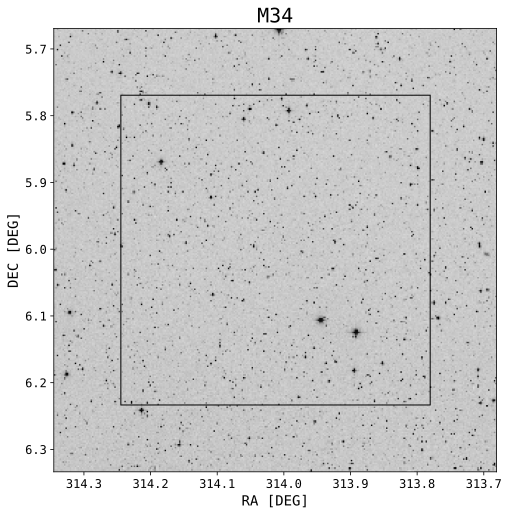

In [58]:
#************
#This block of code allows you to make a finder chart for your cluster using the make_finder() function 
#defined above.
#You will need to do this for each of your three clusters.  
#We provide example code below.

####First, define the RA and DEC of the cluster as follows, in HMS for RA and DMS for DEC
#source_RA = '07 38 46'
#source_DEC = '-33 50 36'
#
####Now, define the fov in arcmin. This should be the fov of your instrument from part 1
#fov = 12.7 -->
#fov_degrees = fov/60
#
#### Now name your cluster
#cluster 'amazingcluster.csv'

#make_finder(source_RA, source_DEC, fov_degrees, title=cluster)
#***********YOUR CODE HERE

source_RA = '20 56 03'
source_DEC = '06 00 05'
fov =  27.85 #in arcmin
fov_degrees = fov/60
cluster = 'M34'
make_finder(source_RA, source_DEC, fov_degrees, title=cluster)